# 01 — Mission Definition & Propulsion Model

**nEUROn v2** — BWB Flying Wing Design Optimization

This notebook defines the mission envelope and propulsion system, establishing
the feasibility constraints that drive the entire design space.

## What this notebook covers
1. Mission parameters (cruise speed, MTOW, altitude)
2. EDF 70mm performance model — thrust curve T(V)
3. Power balance: drag → shaft power → electrical power
4. Endurance & range as function of L/D
5. Geometric constraint: EDF duct must fit inside BWB body
6. Summary of propulsion feasibility thresholds

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import matplotlib.pyplot as plt

from src.propulsion.edf_model import (
    EDF_70MM, EDF_90MM, BATTERY_3S_1300, BATTERY_3S_800, BATTERY_4S_1000,
    thrust_at_speed, thrust_curve, power_required, endurance,
    duct_fits_in_body, min_body_tc_for_duct, intake_drag,
)
from src.aero.mission import MissionCondition, FeasibilityConfig

plt.rcParams.update({"figure.dpi": 120, "font.size": 10})

In [ ]:
%load_ext autoreload
%autoreload 2

## 1. Mission Parameters

Based on Neuronautics NX-2 specification, scaled for BWB UCAV demonstrator.

In [2]:
mission = MissionCondition()

print("═══ Mission Condition ═══")
print(f"  Cruise speed   : {mission.velocity} m/s")
print(f"  Altitude       : {mission.altitude} m")
print(f"  MTOW           : {mission.mtow} kg")
print(f"  Weight         : {mission.weight:.2f} N")
print(f"  Density        : {mission.density:.4f} kg/m³")
print(f"  Dynamic press. : {mission.dynamic_pressure:.2f} Pa")
print(f"  Kin. viscosity : {mission.kinematic_viscosity:.2e} m²/s")
print()
print("═══ Mass Budget ═══")
print(f"  Battery        : {mission.battery_mass:.3f} kg ({mission.battery.name})")
print(f"  Motor (EDF)    : {mission.motor_mass:.3f} kg ({mission.edf.name})")
print(f"  Avionics       : {mission.avionics_mass:.3f} kg")
print(f"  ─────────────────────────────")
print(f"  Airframe budget: {mission.mass_budget:.3f} kg")
print()
print("═══ Propulsion ═══")
print(f"  EDF            : {mission.edf.name}")
print(f"  Fan diameter   : {mission.edf.fan_diameter*1000:.0f} mm")
print(f"  Duct OD        : {mission.edf.duct_outer_diameter*1000:.0f} mm")
print(f"  T_static       : {mission.edf.thrust_static:.1f} N")
print(f"  T @ cruise     : {mission.thrust_available:.2f} N")
print(f"  Battery energy : {mission.battery.energy_wh:.1f} Wh ({mission.battery.energy_j:.0f} J)")

═══ Mission Condition ═══
  Cruise speed   : 20.0 m/s
  Altitude       : 100.0 m
  MTOW           : 1.5 kg
  Weight         : 14.71 N
  Density        : 1.2132 kg/m³
  Dynamic press. : 242.64 Pa
  Kin. viscosity : 1.47e-05 m²/s

═══ Mass Budget ═══
  Battery        : 0.150 kg (3S 1800mAh LiPo)
  Motor (EDF)    : 0.060 kg (EDF 70mm (Schubeler DS-51 class))
  Avionics       : 0.100 kg
  ─────────────────────────────
  Airframe budget: 1.190 kg

═══ Propulsion ═══
  EDF            : EDF 70mm (Schubeler DS-51 class)
  Fan diameter   : 70 mm
  Duct OD        : 78 mm
  T_static       : 10.0 N
  T @ cruise     : 4.29 N
  Battery energy : 19.5 Wh (70200 J)


## 2. EDF Thrust Curve

The EDF produces maximum thrust at zero speed and decreasing thrust as airspeed increases.
We use a conservative linear model: `T(V) = T_static × (1 - V/V_max)`.

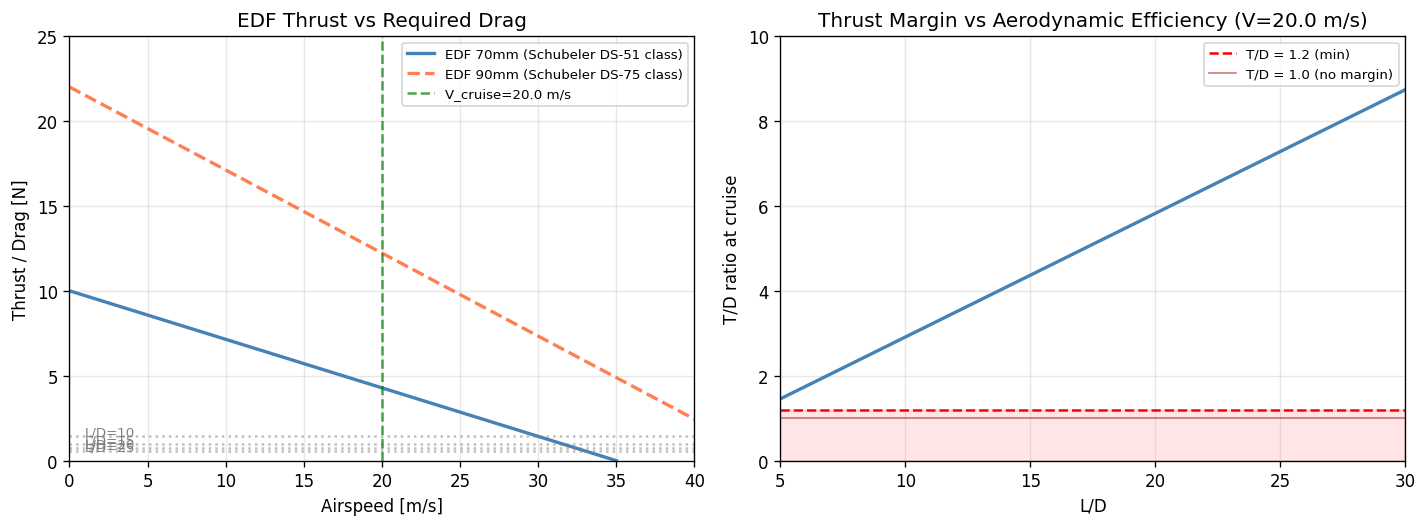

T_available @ 20.0 m/s = 4.29 N
Max drag for T/D>1.2 : 3.57 N → min L/D = 4.1


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Thrust curves for both EDF sizes
for edf, color, ls in [(EDF_70MM, "steelblue", "-"), (EDF_90MM, "coral", "--")]:
    v, t = thrust_curve(edf)
    axes[0].plot(v, t, color=color, ls=ls, lw=2, label=edf.name)

# Drag lines for different L/D values (at MTOW=1kg)
W = mission.weight
S_ref_typical = 0.35  # m² typical wing area
for ld_val in [10, 15, 20, 25]:
    D = W / ld_val
    axes[0].axhline(D, color="gray", ls=":", alpha=0.5)
    axes[0].text(1, D + 0.02, f"L/D={ld_val}", fontsize=8, color="gray")

axes[0].axvline(mission.velocity, color="green", ls="--", alpha=0.7, label=f"V_cruise={mission.velocity} m/s")
axes[0].set_xlabel("Airspeed [m/s]")
axes[0].set_ylabel("Thrust / Drag [N]")
axes[0].set_title("EDF Thrust vs Required Drag")
axes[0].legend(fontsize=8)
axes[0].set_xlim(0, 40)
axes[0].set_ylim(0, 25)
axes[0].grid(True, alpha=0.3)

# T/D ratio at cruise for different L/D
ld_range = np.linspace(5, 30, 100)
D_range = W / ld_range
T_avail = thrust_at_speed(EDF_70MM, mission.velocity)
td_ratio = T_avail / D_range

axes[1].plot(ld_range, td_ratio, "steelblue", lw=2)
axes[1].axhline(1.2, color="red", ls="--", lw=1.5, label="T/D = 1.2 (min)")
axes[1].axhline(1.0, color="darkred", ls="-", lw=1, alpha=0.5, label="T/D = 1.0 (no margin)")
axes[1].fill_between(ld_range, 0, 1.2, alpha=0.1, color="red")
axes[1].set_xlabel("L/D")
axes[1].set_ylabel("T/D ratio at cruise")
axes[1].set_title(f"Thrust Margin vs Aerodynamic Efficiency (V={mission.velocity} m/s)")
axes[1].legend(fontsize=8)
axes[1].set_xlim(5, 30)
axes[1].set_ylim(0, 10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"T_available @ {mission.velocity} m/s = {T_avail:.2f} N")
print(f"Max drag for T/D>1.2 : {T_avail/1.2:.2f} N → min L/D = {W/(T_avail/1.2):.1f}")

## 3. Endurance & Range vs L/D

For a given L/D, we can compute the total drag, power required, and flight time.
This is the key trade: higher L/D → less drag → less power → longer flight.

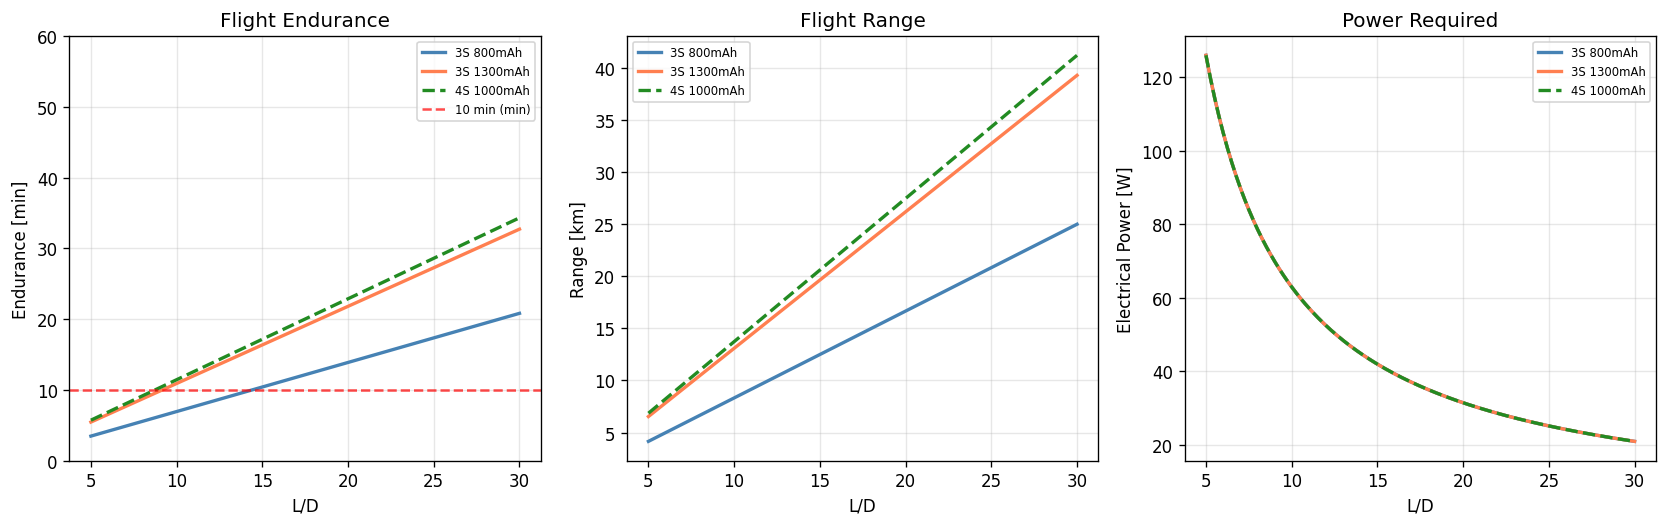

Reference point (L/D=20, 3S 1300mAh):
  Drag        = 0.736 N
  P_thrust    = 14.7 W
  P_shaft     = 26.8 W
  P_elec      = 31.5 W
  T/D         = 5.82
  Endurance   = 21.8 min
  Range       = 26.2 km


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

ld_range = np.linspace(5, 30, 200)
batteries = [
    (BATTERY_3S_800, "3S 800mAh", "steelblue", "-"),
    (BATTERY_3S_1300, "3S 1300mAh", "coral", "-"),
    (BATTERY_4S_1000, "4S 1000mAh", "forestgreen", "--"),
]

for batt, label, color, ls in batteries:
    endurance_min = []
    range_km = []
    p_elec = []
    for ld in ld_range:
        D = W / ld
        result = endurance(D, mission.velocity, EDF_70MM, batt)
        endurance_min.append(result["endurance_min"])
        range_km.append(result["range_km"])
        p_elec.append(result["P_elec"])

    axes[0].plot(ld_range, endurance_min, color=color, ls=ls, lw=2, label=label)
    axes[1].plot(ld_range, range_km, color=color, ls=ls, lw=2, label=label)
    axes[2].plot(ld_range, p_elec, color=color, ls=ls, lw=2, label=label)

# Endurance
axes[0].axhline(10, color="red", ls="--", alpha=0.7, label="10 min (min)")
axes[0].set_xlabel("L/D")
axes[0].set_ylabel("Endurance [min]")
axes[0].set_title("Flight Endurance")
axes[0].legend(fontsize=7)
axes[0].set_ylim(0, 60)
axes[0].grid(True, alpha=0.3)

# Range
axes[1].set_xlabel("L/D")
axes[1].set_ylabel("Range [km]")
axes[1].set_title("Flight Range")
axes[1].legend(fontsize=7)
axes[1].grid(True, alpha=0.3)

# Power
axes[2].set_xlabel("L/D")
axes[2].set_ylabel("Electrical Power [W]")
axes[2].set_title("Power Required")
axes[2].legend(fontsize=7)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Reference point: L/D = 20 with default battery
D_ref = W / 20
result_ref = endurance(D_ref, mission.velocity, EDF_70MM, BATTERY_3S_1300)
print(f"Reference point (L/D=20, 3S 1300mAh):")
print(f"  Drag        = {D_ref:.3f} N")
print(f"  P_thrust    = {result_ref['P_thrust']:.1f} W")
print(f"  P_shaft     = {result_ref['P_shaft']:.1f} W")
print(f"  P_elec      = {result_ref['P_elec']:.1f} W")
print(f"  T/D         = {result_ref['T_over_D']:.2f}")
print(f"  Endurance   = {result_ref['endurance_min']:.1f} min")
print(f"  Range       = {result_ref['range_km']:.1f} km")

## 4. Geometric Constraint — Duct Fit

The EDF duct (78mm OD) must physically fit inside the BWB center body.
The available height is `body_tc × body_chord × 0.80` (80% safety margin for skin + structure).

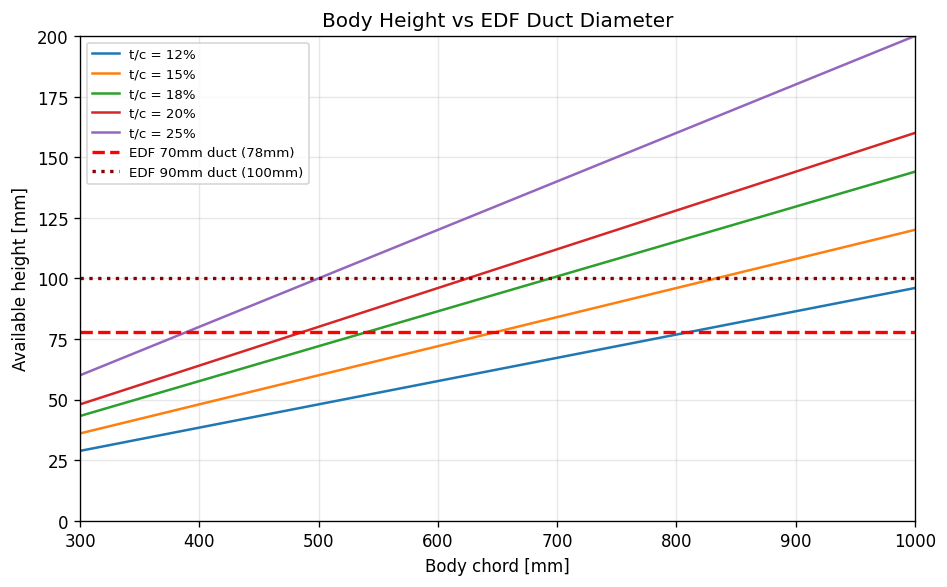

Minimum body t/c to fit EDF 70mm duct:
  chord=350mm → min t/c = 27.9%  (t/c=18% FAIL)
  chord=400mm → min t/c = 24.4%  (t/c=18% FAIL)
  chord=500mm → min t/c = 19.5%  (t/c=18% FAIL)
  chord=600mm → min t/c = 16.2%  (t/c=18% OK)
  chord=700mm → min t/c = 13.9%  (t/c=18% OK)


In [5]:
fig, ax = plt.subplots(figsize=(8, 5))

body_chords = np.linspace(0.30, 1.00, 200)  # body chord [m]
tc_values = [0.12, 0.15, 0.18, 0.20, 0.25]

for tc in tc_values:
    available_h = tc * body_chords * 0.80 * 1000  # [mm]
    ax.plot(body_chords * 1000, available_h, lw=1.5, label=f"t/c = {tc:.0%}")

# Duct diameter lines
ax.axhline(EDF_70MM.duct_outer_diameter * 1000, color="red", ls="--", lw=2,
           label=f"EDF 70mm duct ({EDF_70MM.duct_outer_diameter*1000:.0f}mm)")
ax.axhline(EDF_90MM.duct_outer_diameter * 1000, color="darkred", ls=":", lw=2,
           label=f"EDF 90mm duct ({EDF_90MM.duct_outer_diameter*1000:.0f}mm)")

ax.set_xlabel("Body chord [mm]")
ax.set_ylabel("Available height [mm]")
ax.set_title("Body Height vs EDF Duct Diameter")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_xlim(300, 1000)
ax.set_ylim(0, 200)

plt.tight_layout()
plt.show()

# Show minimum t/c for different body chords
print("Minimum body t/c to fit EDF 70mm duct:")
for chord in [0.35, 0.40, 0.50, 0.60, 0.70]:
    min_tc = min_body_tc_for_duct(chord, EDF_70MM)
    fits = duct_fits_in_body(0.18, chord, EDF_70MM)
    print(f"  chord={chord*1000:.0f}mm → min t/c = {min_tc:.1%}  "
          f"(t/c=18% {'OK' if fits else 'FAIL'})")

## 5. Intake Drag

The NACA flush submerged intake adds a small drag increment proportional to the intake area.

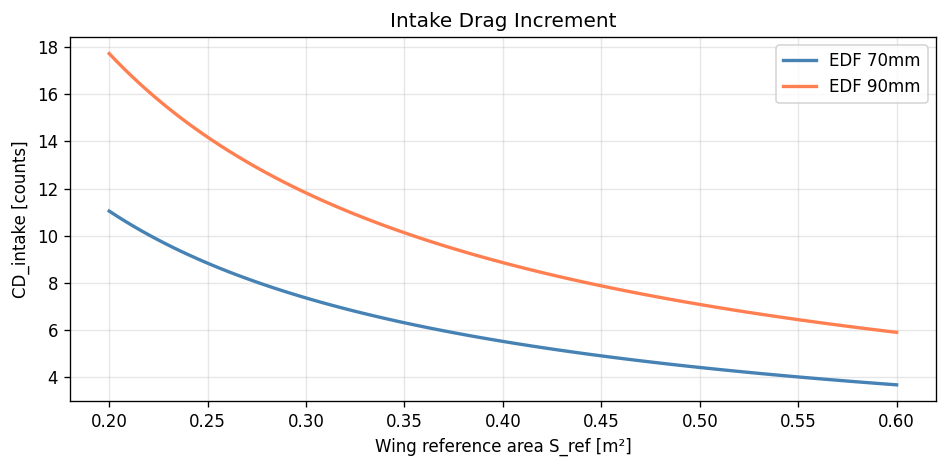

Intake drag for EDF 70mm, S_ref=0.35 m²: CD = 0.000631 (6.3 counts)
For comparison, typical wing CD0 ≈ 0.008-0.012 (80-120 counts)


In [6]:
S_ref_range = np.linspace(0.20, 0.60, 100)
cd_intake_70 = [intake_drag(EDF_70MM, s) for s in S_ref_range]
cd_intake_90 = [intake_drag(EDF_90MM, s) for s in S_ref_range]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(S_ref_range, np.array(cd_intake_70) * 1e4, "steelblue", lw=2, label="EDF 70mm")
ax.plot(S_ref_range, np.array(cd_intake_90) * 1e4, "coral", lw=2, label="EDF 90mm")
ax.set_xlabel("Wing reference area S_ref [m²]")
ax.set_ylabel("CD_intake [counts]")
ax.set_title("Intake Drag Increment")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

cd_ref = intake_drag(EDF_70MM, 0.35)
print(f"Intake drag for EDF 70mm, S_ref=0.35 m²: CD = {cd_ref:.6f} ({cd_ref*1e4:.1f} counts)")
print(f"For comparison, typical wing CD0 ≈ 0.008-0.012 (80-120 counts)")

## 6. Feasibility Summary

All constraints that will be enforced during optimization:

In [7]:
fc = FeasibilityConfig()

print("═══ Feasibility Constraints ═══")
print()
print("Aerodynamic:")
print(f"  Static margin      : [{fc.sm_min:.0%}, {fc.sm_max:.0%}] MAC  (w_lo={fc.w_sm_lo}, w_hi={fc.w_sm_hi})")
print(f"  |CM| at trim       : < {fc.cm_max}                (w={fc.w_trim})")
print(f"  CL_required        : [{fc.cl_min}, {fc.cl_max}]           (w={fc.w_cl})")
print(f"  Aspect ratio       : > {fc.ar_min}                  (w={fc.w_ar})")
print(f"  Internal volume    : > {fc.volume_min*1e6:.0f} cm³            (w={fc.w_volume})")
print(f"  Cn_beta            : > {fc.cn_beta_min}              (w={fc.w_cn_beta})")
print(f"  Struct mass        : < {mission.mass_budget:.3f} kg        (w={fc.w_mass})")
print()
print("Propulsion:")
print(f"  T/D ratio          : > {fc.td_min}                  (w={fc.w_td})")
print(f"  Endurance          : > {fc.endurance_min:.0f} s ({fc.endurance_min/60:.0f} min)       (w={fc.w_endurance})")
print(f"  Duct fits in body  : boolean                (w={fc.w_duct_fit})")
print()
print(f"Total constraints: 9 (6 aero + 3 propulsion)")

═══ Feasibility Constraints ═══

Aerodynamic:
  Static margin      : [5%, 15%] MAC  (w_lo=20.0, w_hi=25.0)
  |CM| at trim       : < 0.2                (w=15.0)
  CL_required        : [0.05, 0.75]           (w=10.0)
  Aspect ratio       : > 5.5                  (w=5.0)
  Internal volume    : > 2000 cm³            (w=15.0)
  Cn_beta            : > 0.005              (w=15.0)
  Struct mass        : < 1.190 kg        (w=10.0)

Propulsion:
  T/D ratio          : > 1.2                  (w=20.0)
  Endurance          : > 600 s (10 min)       (w=15.0)
  Duct fits in body  : boolean                (w=25.0)

Total constraints: 9 (6 aero + 3 propulsion)
